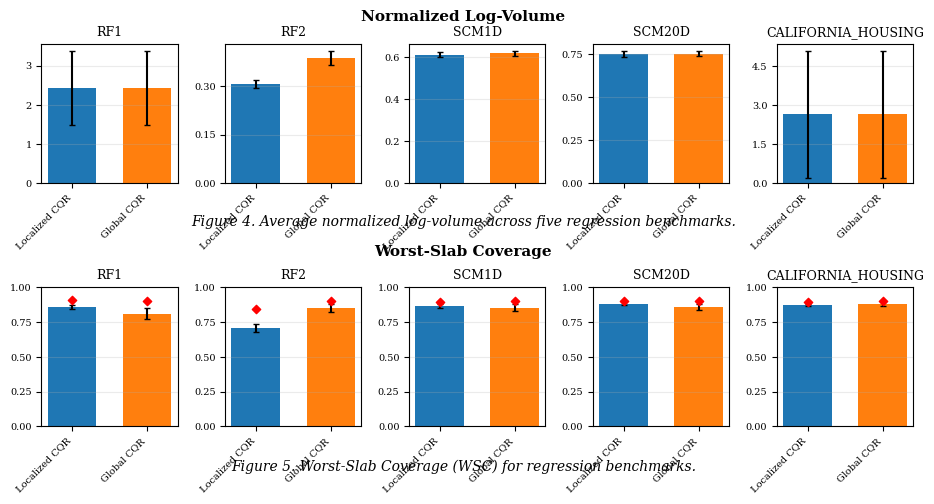

In [3]:
# --- Paper-like multi-panel barplots (like your screenshot) ---
# Works out-of-the-box with your attached CSV structure:
#   - Top row: "Normalized Log-Volume"  (here: log1p(Avg Width) as a proxy)
#   - Bottom row: "Worst-Slab Coverage" (here: Worst-Bin Cov bars + marginal Coverage red diamonds)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_like_paper(
    csv_path="results_real_data.csv",
    target="90%",
    dataset_order=("rf1","rf2","scm1d","scm20d","sgemm"),  # will auto-fill missing to reach max_datasets
    max_datasets=5,

    # Put your method first, then baselines:
    method_order=("Your Method", "Localized CQR", "Global CQR"),

    # ----- TOP PANEL (change these if you already have a volume column) -----
    top_mean_col="Avg Width (mean)",     # if you have it: e.g. "Norm Log-Volume (mean)"
    top_std_col="Avg Width (std)",       # if you have it: e.g. "Norm Log-Volume (std)"
    top_transform="log1p",               # {"none","log","log10","log1p"}

    # ----- BOTTOM PANEL -----
    bottom_mean_col="Worst-Bin Cov (mean)",  # WSC-like
    bottom_std_col="Worst-Bin Cov (std)",
    bottom_marker_col="Coverage (mean)",     # red diamonds (overall marginal coverage)

    figsize_per_col=2.25,
    save_path=None,
):
    df = pd.read_csv(csv_path)

    # filter target coverage (optional)
    if target is not None and "Target Coverage" in df.columns:
        df = df[df["Target Coverage"].astype(str).str.strip() == str(target)]

    # choose datasets: desired order + auto-fill to reach max_datasets
    available_ds = list(df["Dataset"].unique())
    available_set = set(available_ds)
    datasets = [d for d in dataset_order if d in available_set]
    if len(datasets) < max_datasets:
        for d in available_ds:
            if d not in datasets:
                datasets.append(d)
            if len(datasets) >= max_datasets:
                break
    datasets = datasets[:max_datasets]

    # choose methods: your preferred order + append anything else present in CSV
    available_methods = list(df["Method"].unique())
    methods = [m for m in method_order if m in available_methods]
    for m in available_methods:
        if m not in methods:
            methods.append(m)

    # style close to the screenshot
    plt.rcParams.update({
        "font.family": "serif",
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    })

    tab10 = plt.get_cmap("tab10").colors
    color_map = {m: tab10[i % len(tab10)] for i, m in enumerate(methods)}

    pretty_ds = {k: k.upper() for k in datasets}
    pretty_ds.update({"scm1d":"SCM1D","scm20d":"SCM20D","rf1":"RF1","rf2":"RF2","sgemm":"SGEMM"})

    ncols = len(datasets)
    fig, axes = plt.subplots(2, ncols, figsize=(figsize_per_col * ncols, 4.9))
    if ncols == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    bar_width = 0.65

    for j, ds in enumerate(datasets):
        sub = df[df["Dataset"] == ds].set_index("Method")
        x = np.arange(len(methods))

        # -------- Top row --------
        ax = axes[0, j]
        vals, errs = [], []
        for m in methods:
            row = sub.loc[m]
            mu = float(row[top_mean_col])
            sigma = float(row[top_std_col]) if top_std_col in df.columns else 0.0

            if top_transform == "log":
                v = np.log(mu + 1e-12)
                e = sigma / max(mu, 1e-12)                      # delta method (ln)
            elif top_transform == "log10":
                v = np.log10(mu + 1e-12)
                e = (sigma / max(mu, 1e-12)) / np.log(10)       # delta method (log10)
            elif top_transform == "log1p":
                v = np.log1p(mu)
                e = sigma / max(1.0 + mu, 1e-12)                # delta method (log1p)
            else:
                v = mu
                e = sigma

            vals.append(v)
            errs.append(e)

        ax.bar(
            x, vals, yerr=errs, capsize=2, width=bar_width,
            color=[color_map[m] for m in methods], edgecolor="none"
        )
        ax.set_title(pretty_ds.get(ds, ds))
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha="right")
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.grid(axis="y", alpha=0.25)

        # -------- Bottom row --------
        ax = axes[1, j]
        vals, errs, markers = [], [], []
        for m in methods:
            row = sub.loc[m]
            vals.append(float(row[bottom_mean_col]))
            errs.append(float(row[bottom_std_col]) if bottom_std_col in df.columns else 0.0)
            markers.append(float(row[bottom_marker_col]) if bottom_marker_col in df.columns else np.nan)

        ax.bar(
            x, vals, yerr=errs, capsize=2, width=bar_width,
            color=[color_map[m] for m in methods], edgecolor="none"
        )
        if np.isfinite(markers).any():
            ax.scatter(x, markers, marker="D", s=18, color="red", zorder=3)

        ax.set_title(pretty_ds.get(ds, ds))
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha="right")
        ax.yaxis.set_major_locator(MaxNLocator(4))
        ax.grid(axis="y", alpha=0.25)
        ax.set_ylim(0, 1.0)

    # row titles + captions (paper-ish)
    fig.text(0.5, 0.97, "Normalized Log-Volume", ha="center", va="top", fontsize=11, fontweight="bold")
    fig.text(0.5, 0.49, "Worst-Slab Coverage", ha="center", va="top", fontsize=11, fontweight="bold")
    fig.text(0.5, 0.53, "Figure 4. Average normalized log-volume across five regression benchmarks.",
             ha="center", fontsize=10, style="italic")
    fig.text(0.5, 0.03, "Figure 5. Worst-Slab Coverage (WSC) for regression benchmarks.",
             ha="center", fontsize=10, style="italic")

    plt.subplots_adjust(top=0.90, bottom=0.12, wspace=0.35, hspace=0.75)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig


# ---- Run (edit csv_path if needed) ----
fig = plot_like_paper(
    csv_path="results_real_data.csv",
    method_order=("Localized CQR", "Global CQR"),  # your request (only baselines)
    dataset_order=("rf1","rf2","scm1d","scm20d","sgemm"),
    max_datasets=5,
    save_path="fig_style_like_paper.png"
)
plt.show()


In [2]:
%pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 63.9 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 71.7 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 62.1 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pypar